In [1]:
from mylib.statistic_test import *

code_id = '0816 - Revisit aPVC and rPVC'
loc = os.path.join(figpath, 'Dsp', code_id)
os.makedirs(loc, exist_ok=True)

d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


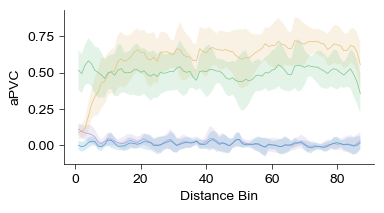

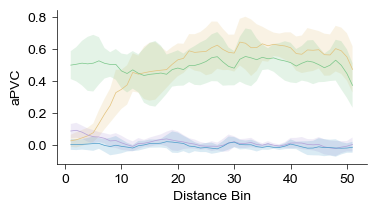

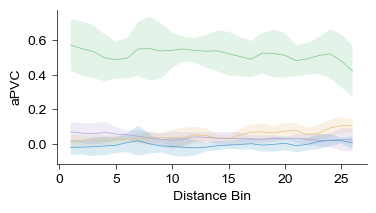

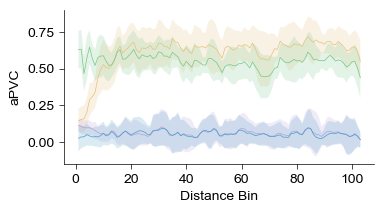

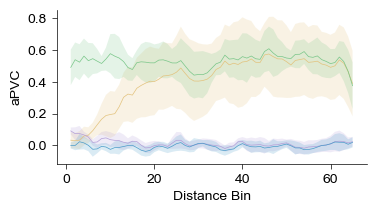

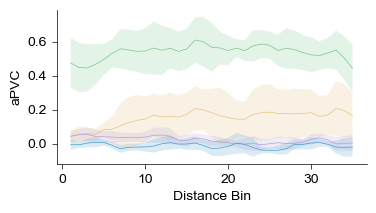

In [2]:
if exists(join(figdata, f"{code_id}.pkl")) == False:
    PVCs = {
        'MiceID': [],
        'Route': [],
        'Nodes': [],
        'Session': [],
        'Distance': [],
        'aPVC': [],
        'rPVC': [],
        'Type': []
    }
    D = GetDMatrices(1, 48)

    for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
        file_idx = np.where(f2['MiceID'] == mouse)[0]
        for s in tqdm(range(7)):
            with open(f2['Trace File'][file_idx[s]], 'rb') as f:
                trace = pickle.load(f)
                
            for rt, nodes in zip([1,2,3,4,5,6], [1,2,3,6,7,8]):
                targ_nodes = 0 if rt in [1,2,3] else 5
                targ_nodes2 = 4 if rt in [1,2,3] else 9
                
                son_bins_rt = np.concatenate([Father2SonGraph[b] for b in CP_DSPs[trace['maze_type']][rt]])
                n_bin = CP_DSPs[trace['maze_type']][rt].shape[0]
                sp_rt = SP_DSPs[trace['maze_type']][rt]
                son_bins_r0 = np.concatenate([Father2SonGraph[b] for b in CP_DSPs[trace['maze_type']][0]])
                son_bins_r0_ctrl = np.concatenate([Father2SonGraph[b] for b in CP_DSPs[trace['maze_type']][0][-n_bin:]])
                
                assert son_bins_r0_ctrl.shape[0] == son_bins_rt.shape[0]
                sp_r0 = SP_DSPs[trace['maze_type']][0] # Starting Point
                
                argsort_rt = np.argsort(D[son_bins_rt-1, sp_rt-1])
                argsort_r0 = np.argsort(D[son_bins_r0-1, sp_r0-1])
                
                sorted_sonbins_rt = son_bins_rt[argsort_rt]
                sorted_sonbins_r0 = son_bins_r0[argsort_r0][:argsort_r0.shape[0]]
                sorted_sonbins_r0_ctrl = son_bins_r0_ctrl[argsort_rt]

                
                dd_rt = D[sorted_sonbins_rt-1, sp_rt-1]
                placecell_idx = np.where(
                    (trace[f'node {targ_nodes}']['is_placecell'] == 1) |
                    (trace[f'node {targ_nodes2}']['is_placecell'] == 1)
                )[0]
                
                # compute rPVC            
                apvc = np.zeros(dd_rt.shape)
                rpvc = np.zeros(dd_rt.shape)
                apvc_ctrl = np.zeros(dd_rt.shape)
                rpvc_ctrl = np.zeros(dd_rt.shape)
                
                smooth_map = trace[f'node {nodes}']['smooth_map_all'][placecell_idx]
                smooth_map_targ = trace[f'node {targ_nodes}']['smooth_map_all'][placecell_idx]
                smooth_map_targ2 = trace[f'node {targ_nodes2}']['smooth_map_all'][placecell_idx]
                
                for i in range(dd_rt.shape[0]):
                    apvc[i] = np.corrcoef(
                        smooth_map[:, sorted_sonbins_rt[i]-1],
                        smooth_map_targ[:, sorted_sonbins_rt[i]-1]
                    )[0,1]
                    rpvc[i] = np.corrcoef(
                        smooth_map[:, sorted_sonbins_rt[i]-1],
                        smooth_map_targ[:, sorted_sonbins_r0[i]-1]
                    )[0,1]
                    apvc_ctrl[i] = np.corrcoef(
                        smooth_map_targ2[:, sorted_sonbins_r0_ctrl[i]-1],
                        smooth_map_targ[:, sorted_sonbins_r0_ctrl[i]-1]
                    )[0,1]
                    rpvc_ctrl[i] = np.corrcoef(
                        smooth_map_targ2[:, sorted_sonbins_r0_ctrl[i]-1],
                        smooth_map_targ[:, sorted_sonbins_r0[i]-1]
                    )[0,1]

                for dt in [0, 1]:
                    PVCs['MiceID'].append(np.repeat(mouse, dd_rt.shape[0]))
                    PVCs['Route'].append(np.repeat(rt, dd_rt.shape[0]))
                    PVCs['Nodes'].append(np.repeat(nodes, dd_rt.shape[0]))
                    PVCs['Session'].append(np.repeat(s, dd_rt.shape[0]))
                    PVCs['Distance'].append(dd_rt)
                    PVCs['aPVC'].append(apvc if dt == 0 else apvc_ctrl)
                    PVCs['rPVC'].append(rpvc if dt == 0 else rpvc_ctrl)
                    PVCs['Type'].append(np.repeat("Data" if dt == 0 else "Ctrl", dd_rt.shape[0]))
            
            del trace
            
    for key in PVCs.keys():
        PVCs[key] = np.concatenate(PVCs[key])
    with open(join(figdata, f"{code_id}.pkl"), 'wb') as f:
        pickle.dump(PVCs, f)

    PVCsD = pd.DataFrame(PVCs)
    PVCsD.to_excel(join(figdata, f"{code_id}.xlsx"), index=False)
    print(len(PVCsD)) 
else:
    with open(join(figdata, f"{code_id}.pkl"), 'rb') as f:
        PVCs = pickle.load(f)
    
D = GetDMatrices(1, 48)
PVCs['Distance Bin'] = ((PVCs['Distance'] / (np.max(D)+1e-10) * 111)//1).astype(np.int64)

if exists(join(figdata, f"{code_id} [Avg].pkl")) == False:
    avg_PVCs = {
        'MiceID': [],
        'Route': [],
        'Distance Bin': [],
        'aPVC': [],
        'rPVC': [],
        'Type': []
    }
        
    for mouse in tqdm([10212, 10224, 10227, 10232, 10275, 10276]):
        for rt in range(1,7):
            for b in range(1, 110):
                for ttype in ['Data', 'Ctrl']:
                    idx = np.where((PVCs['Route'] == rt)&(PVCs['MiceID'] == mouse)&(PVCs['Distance Bin'] == b)&(PVCs['Type'] == ttype))[0]
                    if len(idx) > 0:
                        avg_PVCs['MiceID'].append(mouse)
                        avg_PVCs['Route'].append(rt)
                        avg_PVCs['Distance Bin'].append(b)
                        avg_PVCs['aPVC'].append(np.nanmean(PVCs['aPVC'][idx]))
                        avg_PVCs['rPVC'].append(np.nanmean(PVCs['rPVC'][idx]))
                        avg_PVCs['Type'].append(PVCs['Type'][idx][0])

    for key in avg_PVCs.keys():
        avg_PVCs[key] = np.asarray(avg_PVCs[key])
    with open(join(figdata, f"{code_id} [Avg].pkl"), 'wb') as f:
        pickle.dump(avg_PVCs, f)

    avg_PVCsD = pd.DataFrame(avg_PVCs)
    avg_PVCsD.to_excel(join(figdata, f"{code_id} [Avg].xlsx"), index=False)
    print(len(avg_PVCsD))
else:
    with open(join(figdata, f"{code_id} [Avg].pkl"), 'rb') as f:
        avg_PVCs = pickle.load(f)

D = GetDMatrices(1, 48)
PVCs['Distance'] = ((PVCs['Distance'] / (np.max(D)+1e-10) * 111)//1).astype(np.int64) * 8

for rt in [1,2,3,4,5,6]:
    subdata_rt = SubDict(
        avg_PVCs,
        avg_PVCs.keys(),
        np.where((avg_PVCs['Route'] == rt))[0]
    )
    plt.figure(figsize=(4,2))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    sns.lineplot(
        x='Distance Bin',
        y='aPVC',
        data=subdata_rt,
        hue='Type',
        
        palette=["#e3c27c", "#78c688"],
        linewidth=0.5,
        err_kws={'edgecolor': None},
        legend=False,
        errorbar='sd'
    )
    sns.lineplot(
        x='Distance Bin',
        y='rPVC',
        data=subdata_rt,
        hue='Type',
        linewidth=0.5,
        palette=['#b39fd8', '#4a9bc9'],
        err_kws={'edgecolor': None},
        legend=False,
        errorbar='sd'
    )
    plt.show()


Route 1: t=6.777, p=0.001
Route 2: t=3.633, p=0.015
Route 3: t=5.012, p=0.004
Route 4: t=1.970, p=0.106
Route 5: t=6.823, p=0.001
Route 6: t=2.330, p=0.067


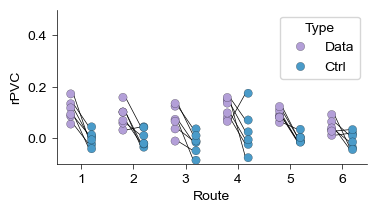

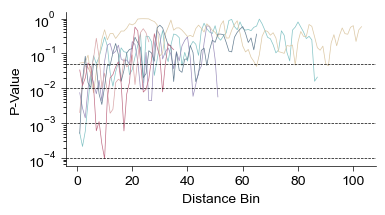

In [12]:
plt.figure(figsize=(4,2))
subdata = SubDict(
    avg_PVCs,
    avg_PVCs.keys(),
    np.where((avg_PVCs['Distance Bin'] == 1))[0]
)
        
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.stripplot(
    x='Route',
    y='rPVC',
    data=subdata,
    hue='Type',
    dodge=True,
    palette=['#b39fd8', '#4a9bc9'],
    jitter=0,
    linewidth=0.15,
    edgecolor='k',
    size=6
)
for rt in [1,2,3,4,5,6]:
    subdata_rt = SubDict(
        subdata,
        subdata.keys(),
        np.where((subdata['Route'] == rt)&(subdata['Distance Bin'] == 1))[0]
    )
    data_rt = subdata_rt['rPVC'][subdata_rt['Type'] == 'Data']
    ctrl_rt = subdata_rt['rPVC'][subdata_rt['Type'] == 'Ctrl']
    stat, p = ttest_rel(data_rt, ctrl_rt)
    print(f"Route {rt}: t={stat:.3f}, p={p:.3f}")
    for i in range(data_rt.shape[0]):
        ax.plot(
            [rt-1-0.15, rt-1+0.15],
            [data_rt[i], ctrl_rt[i]],
            color='k',
            linewidth=0.5,
            zorder=0
        )

ax.set_ylim(-0.1, 0.5)
plt.show()

if exists(join(figdata, f"{code_id} [Stats].pkl")) == False:
    avgPvalues = {
        'Route': [],
        'Distance Bin': [],
        'P-Value': []
    }
    
    for rt in range(1,7):
        for b in range(1, 110):
            data_idx = np.where((avg_PVCs['Route'] == rt)&(avg_PVCs['Distance Bin'] == b)&(avg_PVCs['Type'] == 'Data'))[0]
            ctrl_idx = np.where((avg_PVCs['Route'] == rt)&(avg_PVCs['Distance Bin'] == b)&(avg_PVCs['Type'] == 'Ctrl'))[0]
            res = ttest_rel(avg_PVCs['rPVC'][data_idx], avg_PVCs['rPVC'][ctrl_idx], alternative='greater')
            avgPvalues['Route'].append(rt)
            avgPvalues['Distance Bin'].append(b)
            avgPvalues['P-Value'].append(res.pvalue)
    
    for key in avgPvalues.keys():
        avgPvalues[key] = np.asarray(avgPvalues[key])
        
    with open(join(figdata, f"{code_id} [Stats].pkl"), 'wb') as f:
        pickle.dump(avgPvalues, f)
        
    AvgPvaluesD = pd.DataFrame(avgPvalues)
    AvgPvaluesD.to_excel(join(figdata, f"{code_id} [Stats].xlsx"), index=False)
    print(len(AvgPvaluesD))
else:
    with open(join(figdata, f"{code_id} [Stats].pkl"), 'rb') as f:
        avgPvalues = pickle.load(f)
        

fig = plt.figure(figsize=(4,2))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='Distance Bin',
    y='P-Value',
    data=avgPvalues,
    hue='Route',
    palette=DSPPalette[1:7],
    linewidth=0.5,
    err_kws={'edgecolor': None},
    legend=False,
)
ax.semilogy()
ax.axhline(0.05, color='k', linestyle='--', linewidth=0.5)
ax.axhline(0.01, color='k', linestyle='--', linewidth=0.5)
ax.axhline(0.001, color='k', linestyle='--', linewidth=0.5)
ax.axhline(0.0001, color='k', linestyle='--', linewidth=0.5)
plt.show()

0.11354411543549833 0.4135630382847843


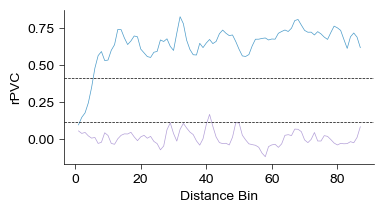

0.09041148026367532 0.3255712454912505


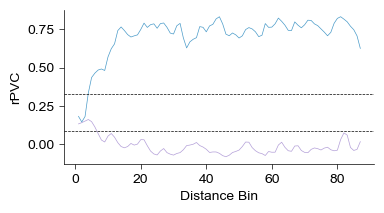

0.042012979289199656 0.3756844370823027


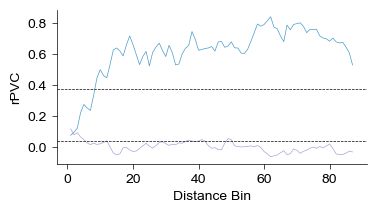

0.0692795869357722 0.5386119090050135


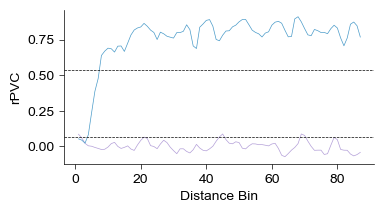

0.09515672984458562 0.25008740507506355


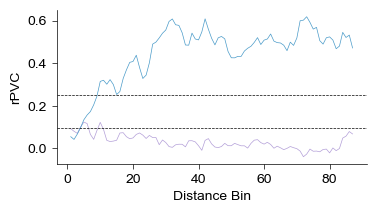

0.1384226763193715 0.21212390231666328


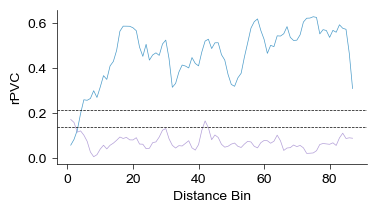

0.045692965160771835 0.42230344523863506


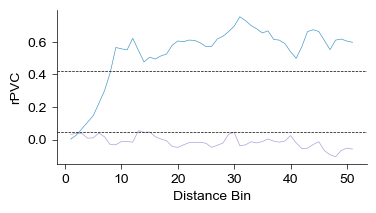

0.02855203186730248 0.3194854351584204


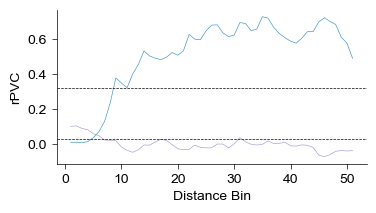

0.06396244469495346 0.37935404423493607


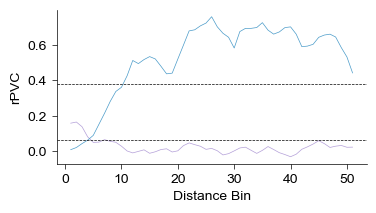

0.06337457855294851 0.5670083156989607


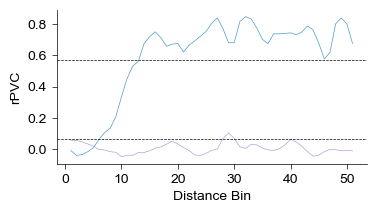

0.04090101423805338 0.24090468540193868


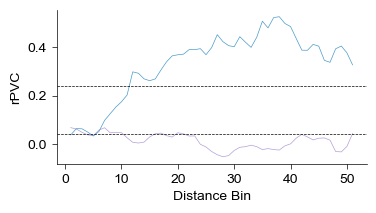

0.12919417016944998 0.2230787731578585


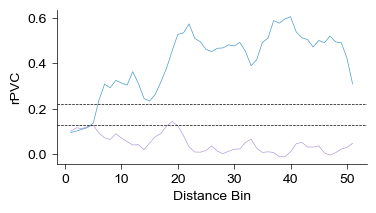

0.15638566784487443 0.5069441115986756


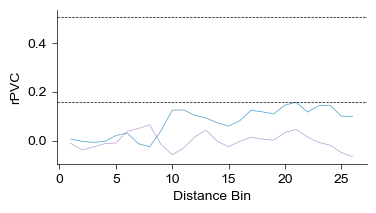

0.045222142696512806 0.3491129774398566


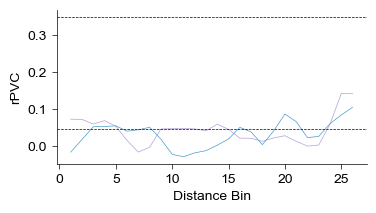

0.03448719742007981 0.45402194974388005


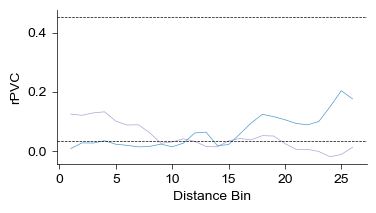

0.039937142553606364 0.5770900159410455


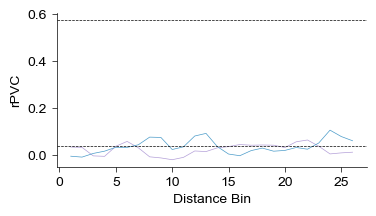

0.00795873795996714 0.261805955604549


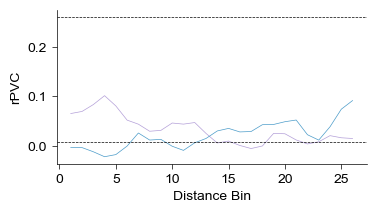

0.05485181578157475 0.3410893405913669


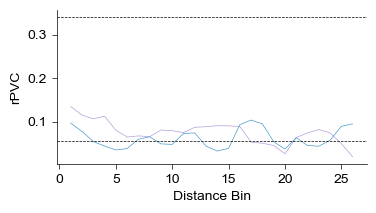

0.1707434746909642 0.44076484252492515


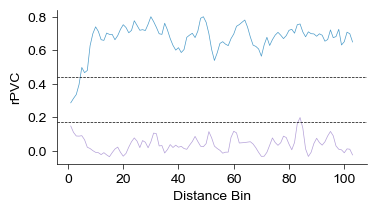

0.10692855410822538 0.41958040733078555


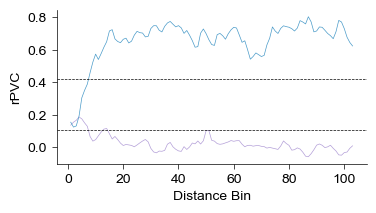

0.02625360502851492 0.40093041047452055


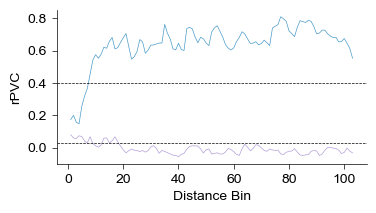

0.05009801938064771 0.5417926292411434


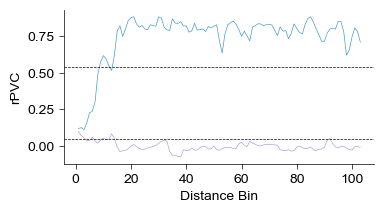

0.28136859128754454 0.3158813337224544


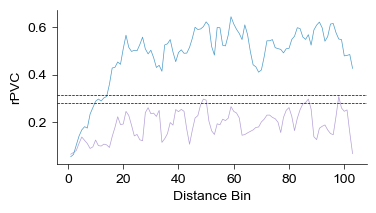

0.2823502823975811 0.26811331511968833


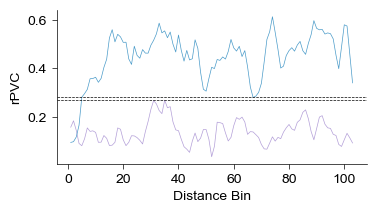

0.08251832494841273 0.43607401912582905


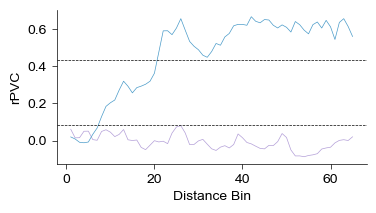

0.02808800524169308 0.39840578841285496


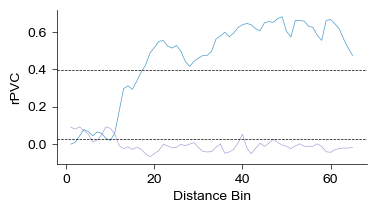

0.07733224347846052 0.3696980262890502


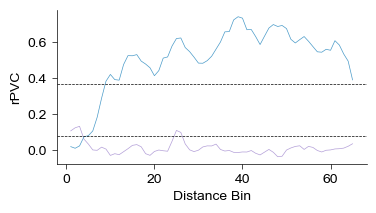

0.0413786916362437 0.5442292519504245


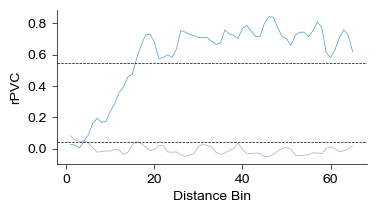

0.05445197034128185 0.3017466418179905


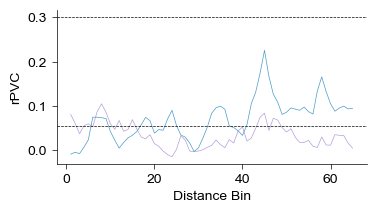

0.12307708272130222 0.23536994255928623


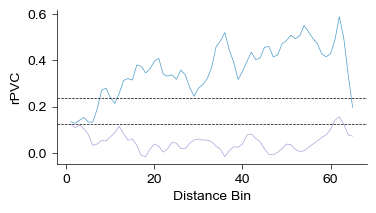

0.075677236356439 0.455152019882543


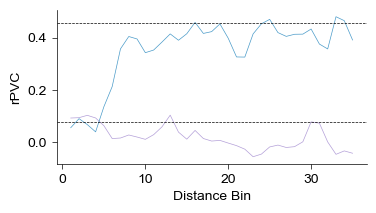

0.04437356225166768 0.4324939007023157


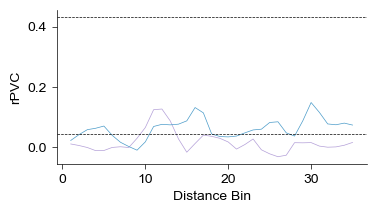

0.031823329588450154 0.42199960049610113


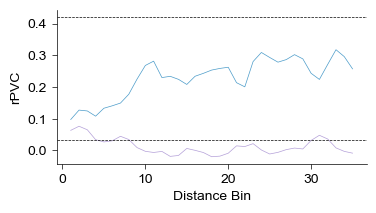

0.03655473416321139 0.5603101456231505


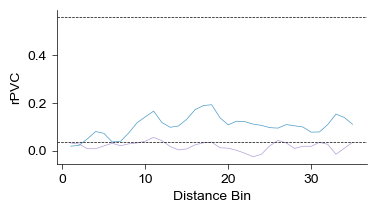

0.03272848315896366 0.3261539028871869


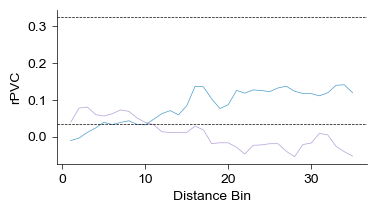

0.10917944423549474 0.27074242130241366


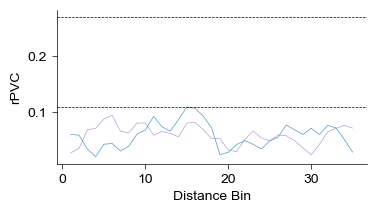

In [14]:
for rt in [1,2,3,4,5,6]:
    for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
        subdata_rt = SubDict(
            avg_PVCs,
            avg_PVCs.keys(),
            np.where((avg_PVCs['Route'] == rt)&(avg_PVCs['MiceID'] == mouse)&(avg_PVCs['Type'] == 'Data'))[0]
        )
        ctrl_idx = np.where((avg_PVCs['Route'] == rt)&(avg_PVCs['Type'] == 'Ctrl')&(avg_PVCs['MiceID'] == mouse))[0]
        top_line = np.percentile(avg_PVCs['rPVC'][ctrl_idx], 99)
        bottom_line = np.percentile(avg_PVCs['aPVC'][ctrl_idx], 1)
        print(top_line, bottom_line)
        
        fig = plt.figure(figsize=(4,2))
        ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        sns.lineplot(
            x='Distance Bin',
            y='rPVC',
            data=subdata_rt,
            hue='Type',
            palette=['#b39fd8'],
            linewidth=0.5,
            err_kws={'edgecolor': None},
            legend=False,
            errorbar='sd'
        )
        sns.lineplot(
            x='Distance Bin',
            y='aPVC',
            data=subdata_rt,
            hue='Type',
            palette=['#4a9bc9'],
            linewidth=0.5,
            err_kws={'edgecolor': None},
            legend=False,
            errorbar='sd'
        )
        plt.axhline(top_line, color='k', linestyle='--', linewidth=0.5)
        plt.axhline(bottom_line, color='k', linestyle='--', linewidth=0.5)
        plt.show()